In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [2]:
# Load Dataset
df = pd.read_csv('Student_data.csv')

df.head()

,student_id,age,gender,state,city_tier,college_tier,branch,degree,cgpa,backlog_history,attendance_percentage,primary_language,DSA_problems_solved,GitHub_repos,hackathons_participated,development_projects_count,AI_ML_projects,internships_completed,resume_score,communication_skills,aptitude_score,mock_interview_score,sleep_hours,screen_time,gaming_hours,study_hours_daily,stress_level,burnout_score,gym_frequency,family_income_lpa,self_learning_hours,motivation_level,placement_status,company_type,work_mode,salary_lpa,interview_rounds_cleared,offer_count,joining_delay_months,layoffs_risk_score,AI_tool_usage_frequency,prompt_engineering_skill,AI_fear_score,adaptability_score
0,STU00001,22,Male,Karnataka,1,2,Computer Science,MCA,6.71,3,75.5,C++,656,10.0,2,5,0,1,55,97,100,NaN,5.7,7.7,1.5,8.0,71,34,0,5.00,2.7,60,Placed,Startup,Remote,17.36,4,1,2,62,55,55,19,81
1,STU00002,20,Male,Tamil Nadu,2,3,AI & DS,BTech,6.14,0,84.4,Rust,619,16.0,1,7,1,6,100,64,97,80.0,5.3,8.2,0.1,5.7,52,58,6,2.47,4.3,82,Placed,MNC,Onsite,18.22,3,3,0,55,66,52,54,76
2,STU00003,23,Female,Uttar Pradesh,3,2,Computer Science,BTech,7.11,0,80.6,Java,674,30.0,3,10,5,3,100,93,83,81.0,4.9,8.3,0.0,7.2,47,50,5,3.65,3.5,50,Placed,Startup,Remote,22.08,1,3,1,79,69,67,49,34
3,STU00004,25,Male,Maharashtra,2,3,Civil,BTech,7.41,0,69.2,Rust,637,15.0,3,7,5,3,87,100,96,100.0,6.4,8.7,2.4,7.7,47,41,2,4.40,3.7,67,Placed,Product-Based,Remote,20.87,2,1,2,44,44,65,61,46
4,STU00005,25,Female,West Bengal,3,3,Civil,BE,8.29,0,76.6,Java,986,12.0,0,2,1,1,68,100,84,68.0,4.8,6.9,3.6,10.2,40,68,2,12.11,4.9,66,Placed,Startup,Onsite,20.57,5,3,5,23,57,67,71,44


In [ ]:
# Basic Exploration
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

df.columns

(25000, 44)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  25000 non-null  object 
 1   age                         25000 non-null  int64  
 2   gender                      25000 non-null  object 
 3   state                       25000 non-null  object 
 4   city_tier                   25000 non-null  int64  
 5   college_tier                25000 non-null  int64  
 6   branch                      25000 non-null  object 
 7   degree                      25000 non-null  object 
 8   cgpa                        25000 non-null  float64
 9   backlog_history             25000 non-null  int64  
 10  attendance_percentage       25000 non-null  float64
 11  primary_language            25000 non-null  object 
 12  DSA_problems_solved         25000 non-null  int64  
 13  GitHub_repos       

Index(['student_id', 'age', 'gender', 'state', 'city_tier', 'college_tier',
       'branch', 'degree', 'cgpa', 'backlog_history', 'attendance_percentage',
       'primary_language', 'DSA_problems_solved', 'GitHub_repos',
       'hackathons_participated', 'development_projects_count',
       'AI_ML_projects', 'internships_completed', 'resume_score',
       'communication_skills', 'aptitude_score', 'mock_interview_score',
       'sleep_hours', 'screen_time', 'gaming_hours', 'study_hours_daily',
       'stress_level', 'burnout_score', 'gym_frequency', 'family_income_lpa',
       'self_learning_hours', 'motivation_level', 'placement_status',
       'company_type', 'work_mode', 'salary_lpa', 'interview_rounds_cleared',
       'offer_count', 'joining_delay_months', 'layoffs_risk_score',
       'AI_tool_usage_frequency', 'prompt_engineering_skill', 'AI_fear_score',
       'adaptability_score'],
      dtype='object')

In [ ]:
# Checking Target Variable
df['salary_lpa'].describe()

,salary_lpa
count,25000.000000
mean,19.006936
std,4.244388
min,0.000000
25%,16.750000
50%,19.130000
75%,21.570000
max,35.100000


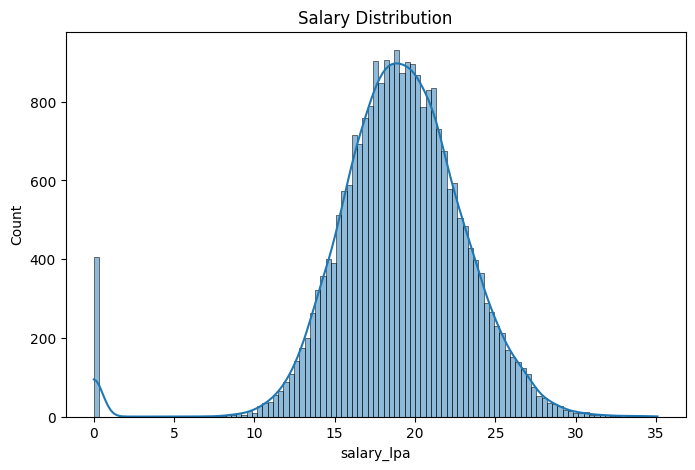

In [ ]:
# Plotting a Histogram to identify salary distribution
plt.figure(figsize=(8,5))
sns.histplot(df['salary_lpa'], kde=True)
plt.title('Salary Distribution')
plt.show()

In [3]:
# Checking whether all students with salary = 0 are "Not Placed
(df['salary_lpa'] == 0).sum()

np.int64(404)

In [4]:
df[df['salary_lpa'] == 0][['placement_status', 'salary_lpa']].head()

,placement_status,salary_lpa
176,Not Placed,0.0
185,Not Placed,0.0
271,Not Placed,0.0
275,Not Placed,0.0
308,Not Placed,0.0


In [5]:
pd.crosstab(
    df['placement_status'],
    df['salary_lpa'] == 0
)

salary_lpa,False,True
placement_status,,
Not Placed,0,404
Placed,24596,0


In [6]:
df.shape

(25000, 44)

In [7]:
#crating a data frame containing only placed studnets
salary_df = df[df['salary_lpa'] > 0].copy()

print(salary_df.shape)

(24596, 44)


In [8]:
salary_df['placement_status'].value_counts()

,count
placement_status,
Placed,24596


In [9]:
(salary_df['salary_lpa'] == 0).sum()

np.int64(0)

In [10]:
salary_df.isnull().sum().sort_values(ascending=False).head(20)

,0
sleep_hours,491
GitHub_repos,486
mock_interview_score,486
student_id,0
city_tier,0
college_tier,0
branch,0
degree,0
cgpa,0
age,0


In [11]:
salary_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24596 entries, 0 to 24999
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  24596 non-null  object 
 1   age                         24596 non-null  int64  
 2   gender                      24596 non-null  object 
 3   state                       24596 non-null  object 
 4   city_tier                   24596 non-null  int64  
 5   college_tier                24596 non-null  int64  
 6   branch                      24596 non-null  object 
 7   degree                      24596 non-null  object 
 8   cgpa                        24596 non-null  float64
 9   backlog_history             24596 non-null  int64  
 10  attendance_percentage       24596 non-null  float64
 11  primary_language            24596 non-null  object 
 12  DSA_problems_solved         24596 non-null  int64  
 13  GitHub_repos                24110 no

Data Cleaning

In [12]:
#Droping student id
salary_df = salary_df.drop('student_id', axis=1)

In [13]:
#Filling missing values
salary_df['sleep_hours'] = salary_df['sleep_hours'].fillna(
    salary_df['sleep_hours'].median()
)

salary_df['GitHub_repos'] = salary_df['GitHub_repos'].fillna(
    salary_df['GitHub_repos'].median()
)

salary_df['mock_interview_score'] = salary_df['mock_interview_score'].fillna(
    salary_df['mock_interview_score'].median()
)

In [14]:
#verify
salary_df.isnull().sum().sum()

np.int64(0)

In [15]:
#remove unnecessary columns
leakage_cols = [
    'placement_status'
]

salary_df = salary_df.drop(columns=leakage_cols)

In [16]:
#Duplicate check
df.duplicated().sum()

np.int64(0)

Exploratory Data Analysis

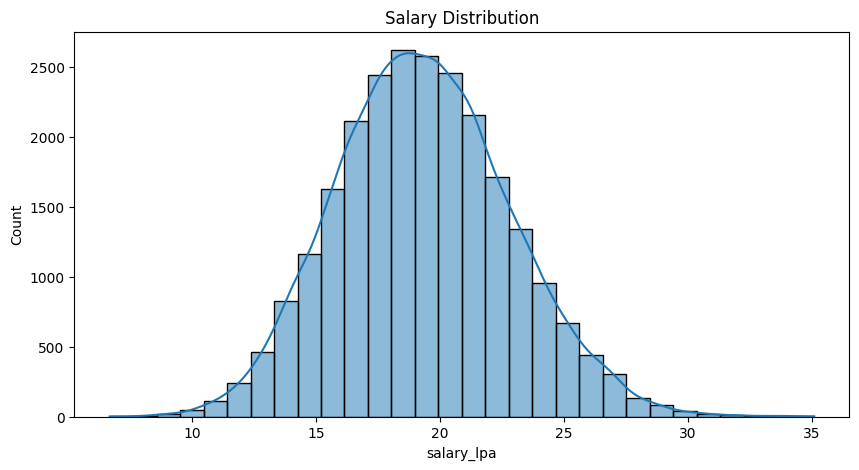

In [ ]:
#Salary Distribution
fig = plt.figure(figsize=(10,5))

sns.histplot(
    salary_df['salary_lpa'],
    bins=30,
    kde=True
)

plt.title('Salary Distribution')

fig.savefig(
    'salary_distribution.png',
    bbox_inches='tight'
)

plt.show()

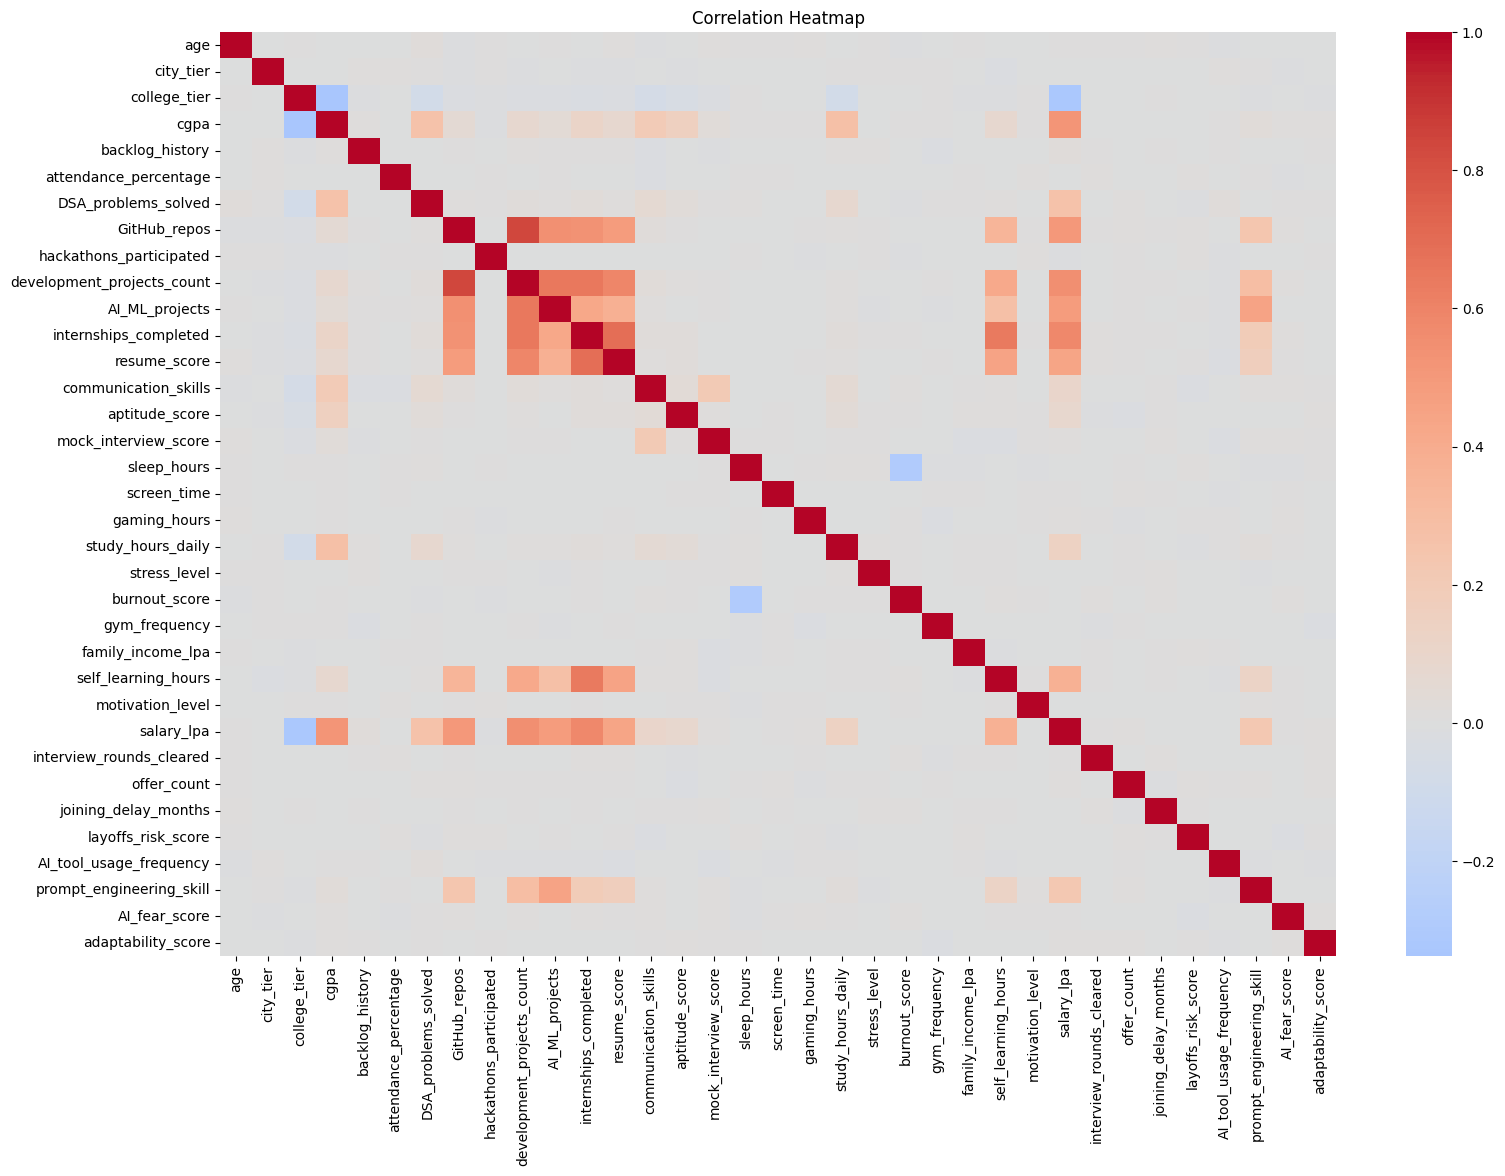

In [ ]:
#Correlation Heatmap
fig = plt.figure(figsize=(18,12))

sns.heatmap(
    salary_df.select_dtypes(include='number').corr(),
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title('Correlation Heatmap')

fig.savefig(
    'correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
#Top Correlations with salary
salary_corr = (
    salary_df
    .select_dtypes(include='number')
    .corr()['salary_lpa']
    .sort_values(ascending=False)
)

salary_corr

,salary_lpa
salary_lpa,1.000000
internships_completed,0.580412
development_projects_count,0.552260
cgpa,0.514513
GitHub_repos,0.508184
AI_ML_projects,0.489337
resume_score,0.444111
self_learning_hours,0.372539
DSA_problems_solved,0.260924
prompt_engineering_skill,0.222608


In [ ]:
salary_corr.head(15)

,salary_lpa
salary_lpa,1.000000
internships_completed,0.580412
development_projects_count,0.552260
cgpa,0.514513
GitHub_repos,0.508184
AI_ML_projects,0.489337
resume_score,0.444111
self_learning_hours,0.372539
DSA_problems_solved,0.260924
prompt_engineering_skill,0.222608


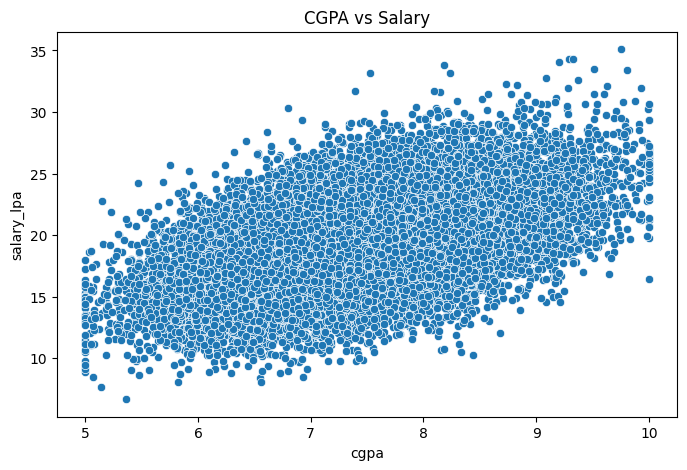

In [ ]:
#Salary vs CGPA
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=salary_df,
    x='cgpa',
    y='salary_lpa'
)

plt.title('CGPA vs Salary')

plt.show()

Observation:
Higher CGPA is positively associated with salary.

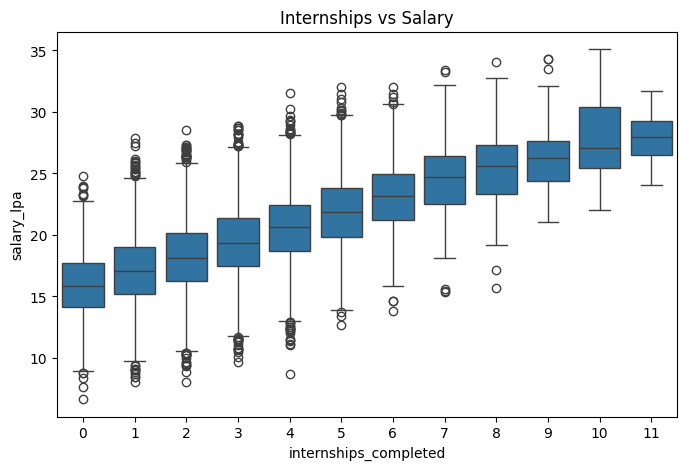

In [ ]:
#Salary vs Internships
plt.figure(figsize=(8,5))

sns.boxplot(
    data=salary_df,
    x='internships_completed',
    y='salary_lpa'
)

plt.title('Internships vs Salary')

plt.show()

Observation:
Students with more internships generally receive higher salary packages.

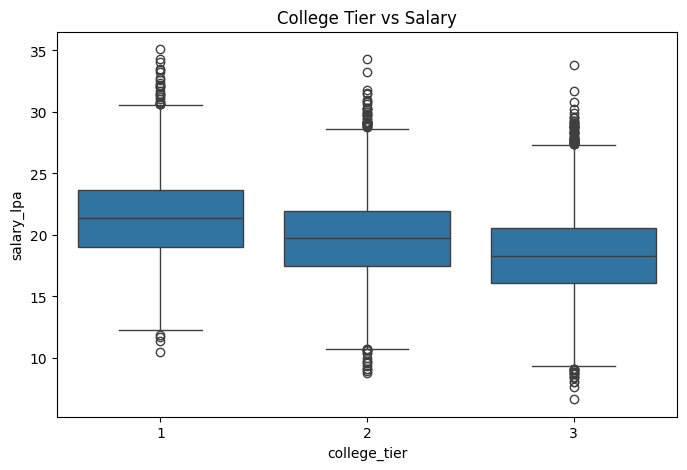

In [ ]:
#Salary vs College Tier
plt.figure(figsize=(8,5))

sns.boxplot(
    data=salary_df,
    x='college_tier',
    y='salary_lpa'
)

plt.title('College Tier vs Salary')

plt.show()

Observation:
Tier 1 college students tend to secure higher salary packages.


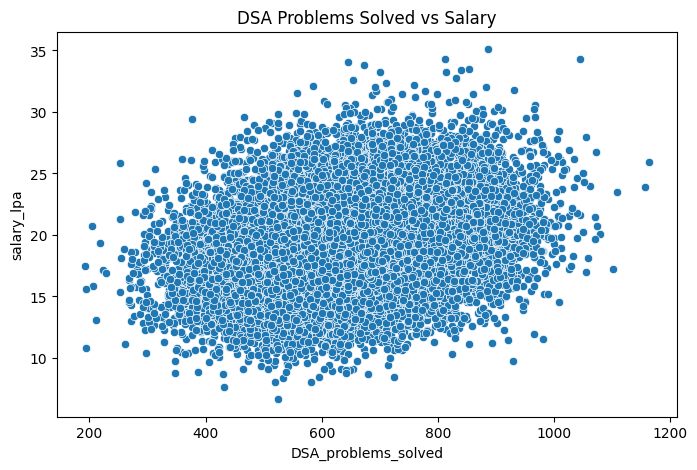

In [ ]:
#Salary vs DSA Problems Solved
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=salary_df,
    x='DSA_problems_solved',
    y='salary_lpa'
)

plt.title('DSA Problems Solved vs Salary')

plt.show()

Observation:
Higher Number of DSA problems solved is positively associated with salary.

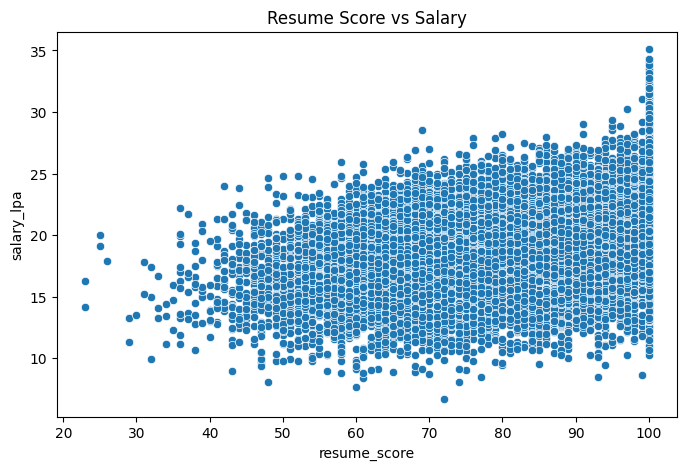

In [ ]:
#Salary vs Resume Score
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=salary_df,
    x='resume_score',
    y='salary_lpa'
)

plt.title('Resume Score vs Salary')

plt.show()

Observation:
Students with higherresume score positively affect on Salary

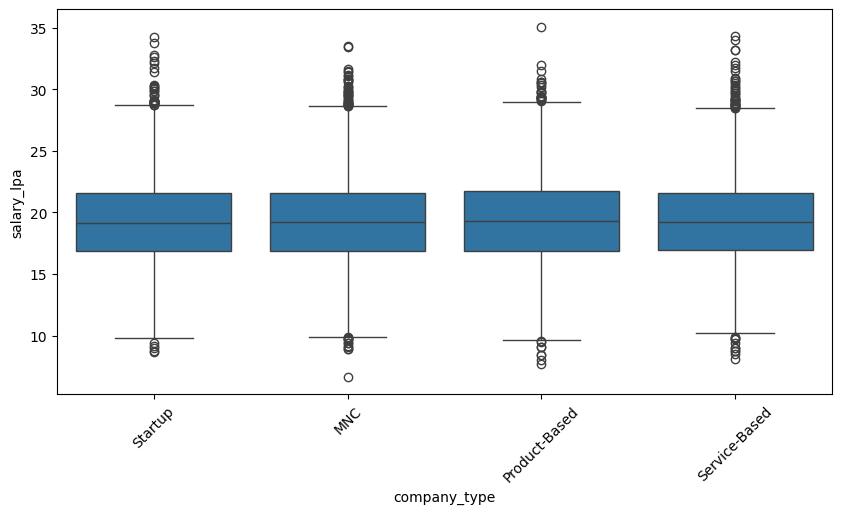

In [ ]:
#Salary by Company Type
plt.figure(figsize=(10,5))

sns.boxplot(
    data=salary_df,
    x='company_type',
    y='salary_lpa'
)

plt.xticks(rotation=45)

plt.show()

Observation: While some company types show slightly higher median salaries, the overall salary distributions overlap considerably. This indicates that individual skills and academic performance may have a greater influence on salary than company type alone.

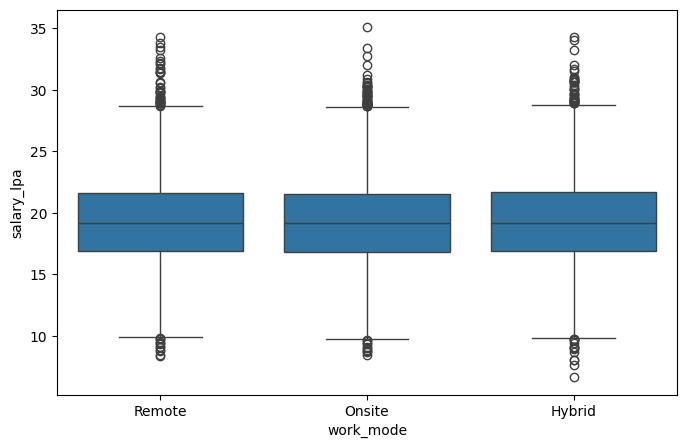

In [ ]:
#Salary by Work Mode
plt.figure(figsize=(8,5))

sns.boxplot(
    data=salary_df,
    x='work_mode',
    y='salary_lpa'
)

plt.show()

Observation: Salary distributions are relatively consistent across different work modes. There is no clear evidence that remote, hybrid, or on-site work arrangements substantially affect salary levels in this dataset.

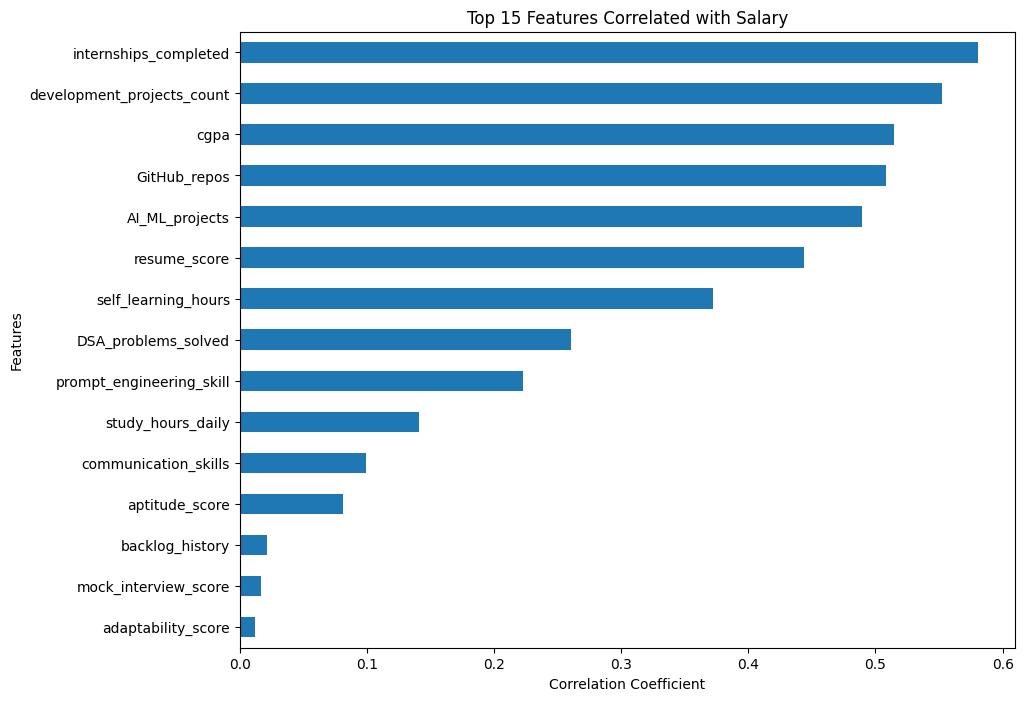

In [ ]:
#Top Numerical features correlated with salary
salary_corr = (
    salary_df
    .select_dtypes(include='number')
    .corr()['salary_lpa']
    .drop('salary_lpa')
    .sort_values(ascending=False)
)

fig = plt.figure(figsize=(10,8))

salary_corr.head(15).sort_values().plot(
    kind='barh'
)

plt.title('Top 15 Features Correlated with Salary')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

fig.savefig(
    'salary_correlations.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Feature Engineering

In [ ]:
#top correlations with salary_lpa
salary_corr.head(15)

,salary_lpa
internships_completed,0.580412
development_projects_count,0.552260
cgpa,0.514513
GitHub_repos,0.508184
AI_ML_projects,0.489337
resume_score,0.444111
self_learning_hours,0.372539
DSA_problems_solved,0.260924
prompt_engineering_skill,0.222608
study_hours_daily,0.140935


In [17]:
salary_df[['offer_count',
           'interview_rounds_cleared',
           'joining_delay_months',
           'salary_lpa']].corr()

,offer_count,interview_rounds_cleared,joining_delay_months,salary_lpa
offer_count,1.000000,-0.007175,-0.008720,0.008097
interview_rounds_cleared,-0.007175,1.000000,0.008275,0.005470
joining_delay_months,-0.008720,0.008275,1.000000,0.001443
salary_lpa,0.008097,0.005470,0.001443,1.000000


Observation:These correlations are essentially zero.

That means these variables have almost no linear relationship with salary in this dataset.

In [19]:
#Decision- remove these columns
leakage_cols = [
    'placement_status',
    'offer_count',
    'interview_rounds_cleared',
    'joining_delay_months'
]

salary_df = salary_df.drop(columns=leakage_cols,errors='ignore')

In [20]:
#Verifying the removal
for col in [
    'placement_status',
    'offer_count',
    'interview_rounds_cleared',
    'joining_delay_months'
]:
    print(col, col in salary_df.columns)

placement_status False
offer_count False
interview_rounds_cleared False
joining_delay_months False


In [21]:
#Seperate features and target
X = salary_df.drop('salary_lpa', axis=1)

y = salary_df['salary_lpa']

In [22]:
#Checking categorical columns
X.select_dtypes(include='object').columns

Index(['gender', 'state', 'branch', 'degree', 'primary_language',
       'company_type', 'work_mode'],
      dtype='object')

In [23]:
#one hot encoding
X = pd.get_dummies(
    X,
    drop_first=True
)

In [24]:
#Verify Shape
print(X.shape)

(24596, 57)


In [25]:
#Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
#Verify
print(X_train.shape)
print(X_test.shape)

(19676, 57)
(4920, 57)


In [27]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(24596, 57)
(19676, 57)
(4920, 57)


Build a Baseline Model

In [37]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [40]:
#Evaluating Linear Regression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE :", mean_absolute_error(y_test, pred_lr))
lr_r2 = r2_score(y_test, pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, pred_lr))

print("R² :", lr_r2)
print("RMSE:", lr_rmse)

MAE : 1.6007509091661414
R² : 0.6725374668029076
RMSE: 2.019603239170666


In [30]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [41]:
#Evaluating Random Forest
print("MAE :", mean_absolute_error(y_test, pred_rf))
rf_r2 = r2_score(y_test, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))

print("R² :", rf_r2)
print("RMSE:", rf_rmse)

MAE : 1.6806628760162603
R² : 0.6404301945613361
RMSE: 2.1162981756269823


In [46]:
#XGBoost Regressor
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

xgb_r2 = r2_score(y_test, pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("R² :", xgb_r2)
print("RMSE:", xgb_rmse)

R² : 0.6594064581338065
RMSE: 2.059697559668922


In [44]:
#Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

gbr_r2 = r2_score(y_test, pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, pred_gbr))

print("R² :", gbr_r2)
print("RMSE:", gbr_rmse)

R² : 0.6634879724665572
RMSE: 2.0473191355811475


In [45]:
#Extra Trees Regressor
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

etr.fit(X_train, y_train)

pred_etr = etr.predict(X_test)

etr_r2 = r2_score(y_test, pred_etr)
etr_rmse = np.sqrt(mean_squared_error(y_test, pred_etr))

print("R² :", etr_r2)
print("RMSE:", etr_rmse)

R² : 0.6444374630492228
RMSE: 2.104472466621735


In [47]:
#Comparing models
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'Extra Trees',
        'XGBoost'
    ],
    'R2': [
        lr_r2,
        rf_r2,
        gbr_r2,
        etr_r2,
        xgb_r2
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        gbr_rmse,
        etr_rmse,
        xgb_rmse
    ]
})

results.sort_values('R2', ascending=False)

,Model,R2,RMSE
0,Linear Regression,0.672537,2.019603
2,Gradient Boosting,0.663488,2.047319
4,XGBoost,0.659406,2.059698
3,Extra Trees,0.644437,2.104472
1,Random Forest,0.640430,2.116298


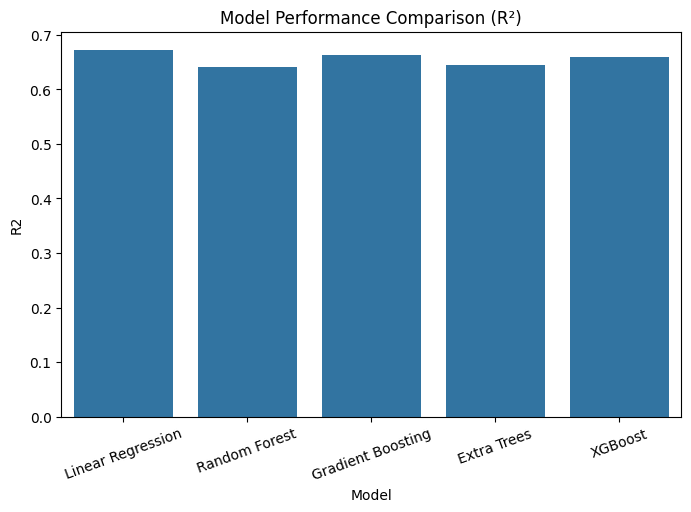

In [49]:
#Creating Model Comparison chart
fig = plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2'
)

plt.xticks(rotation=20)
plt.title('Model Performance Comparison (R²)')

fig.savefig(
    'model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [51]:
#Feature Importance chart
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

importance['Abs_Coefficient'] = importance['Coefficient'].abs()

importance = importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Abs_Coefficient
3,cgpa,1.515525,1.515525
2,college_tier,-0.794374,0.794374
11,internships_completed,0.684620,0.684620
10,AI_ML_projects,0.406677,0.406677
40,branch_Civil,0.090528,0.090528
44,branch_Mechanical,0.084923,0.084923
43,branch_Information Technology,0.077555,0.077555
37,state_Telangana,-0.066935,0.066935
7,GitHub_repos,0.065267,0.065267
41,branch_Computer Science,0.064509,0.064509


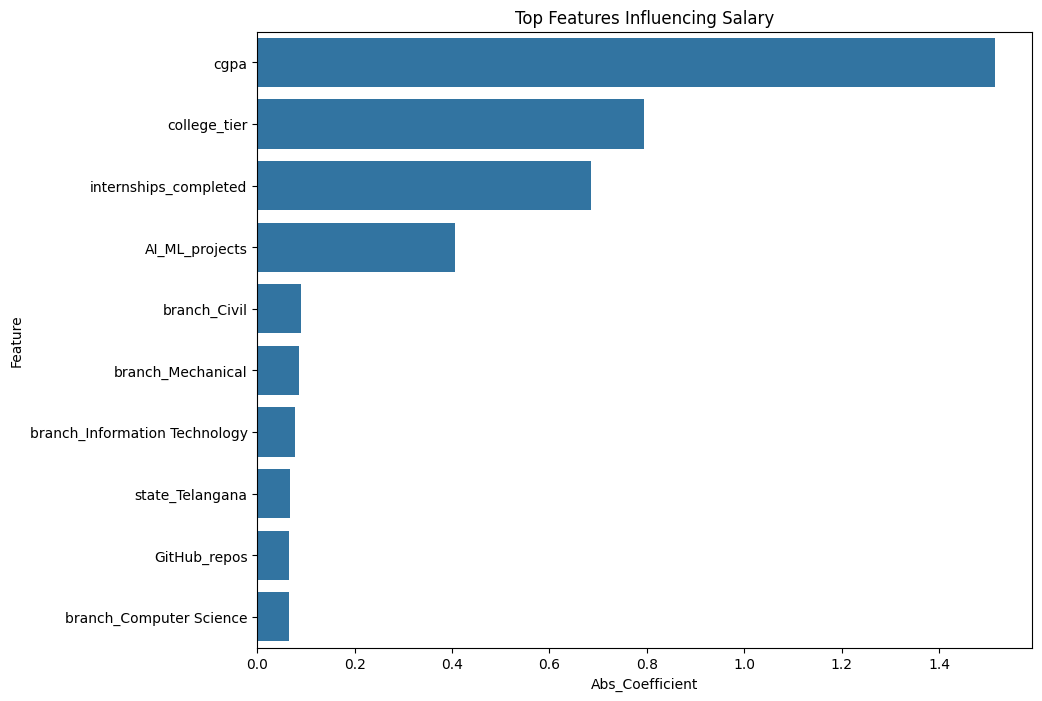

In [53]:
fig = plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(10),
    x='Abs_Coefficient',
    y='Feature'
)

plt.title('Top Features Influencing Salary')

fig.savefig(
    'feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

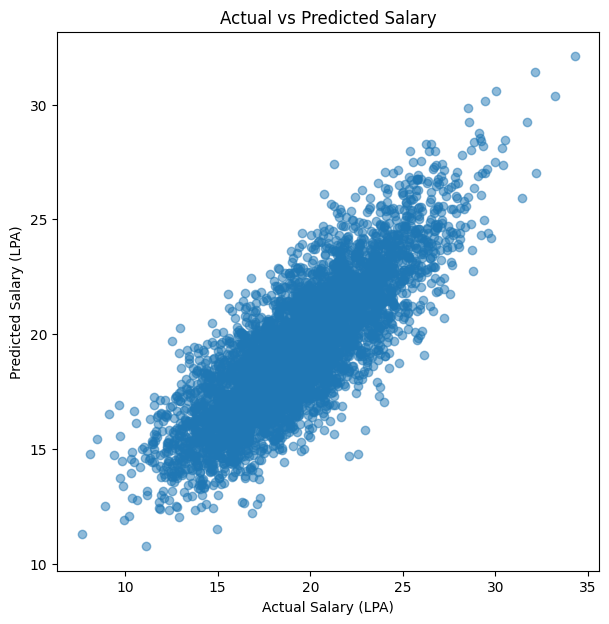

In [54]:
#Actual vs predicted Salary Plot
fig = plt.figure(figsize=(7,7))

plt.scatter(y_test, pred_lr, alpha=0.5)

plt.xlabel('Actual Salary (LPA)')
plt.ylabel('Predicted Salary (LPA)')
plt.title('Actual vs Predicted Salary')

plt.savefig(
    'actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()